In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import fitz
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import subprocess
import re
import string
from pathlib import Path
from types import SimpleNamespace
from collections import defaultdict
from scipy.ndimage import uniform_filter
from scipy.special import logsumexp

from frame_reader import FrameReader
from assignment_model import SlideHandler, EmissionHandler
from util import tokenize, normalize_gray, ocr_crop, find_aoi_corner, TESSERACT_AVAILABLE

print(f'pytesseract {"available" if TESSERACT_AVAILABLE else "not found"} — OCR fallback {"enabled" if TESSERACT_AVAILABLE else "disabled"}')

pytesseract available — OCR fallback enabled


In [2]:
DATA_PATH = '../data/'
VIDEO_PATH = Path(DATA_PATH + 'query_planning.mp4')
PDF_PATH   = Path(DATA_PATH + 'query_planning.pdf')
TXT_PATH   = Path(DATA_PATH + 'query_planning.txt')

TARGET_SIZE      = (128, 128)
TARGET_W, TARGET_H = TARGET_SIZE

DIFF_THRESHOLD   = 1.0        # frame grouping: max mean pixel diff to merge

TOP_K            = 3          # visual: keep top-K slides by L1 distance

P_WORD_IN_SLIDE  = 0.66
P_WORD_NOT_SLIDE = 0.33
MIN_WORD_LEN     = 3

B = 0.1   # P(stay on same slide) per group step

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is',
    'are','was','were','be','been','being','have','has','had','do','does',
    'did','will','would','shall','should','may','might','can','could',
    'not','no','nor','so','yet','both','either','neither','just','also',
    'that','this','these','those','it','its','we','our','you','your',
    'he','she','they','them','then','than','with','from','into','through',
    'about','what','which','who','how','when','where','why','if','as',
    'by','up','out','over','some','all','each','every','more','other',
    'there','their','here'
}

In [3]:
# ── Parse transcript timestamps ────────────────────────────────────────────────
# Reads query_planning.txt produced by transcribe.py.
# Output: segments — sorted list of SimpleNamespace(.start, .end, .text)

_TS_RE = re.compile(r'\[(\d{2}:\d{2}:\d{2}\.\d+) --> (\d{2}:\d{2}:\d{2}\.\d+)\]')

def ts_to_sec(ts: str) -> float:
    h, m, s = ts.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

segments = []
cur_start = cur_end = None
text_lines = []

with open(TXT_PATH, 'r') as fh:
    for line in fh:
        line = line.rstrip('\n')
        m = _TS_RE.match(line)
        if m:
            if cur_start is not None and text_lines:
                segments.append(SimpleNamespace(
                    start=cur_start, end=cur_end,
                    text=' '.join(text_lines)
                ))
            cur_start = ts_to_sec(m.group(1))
            cur_end   = ts_to_sec(m.group(2))
            text_lines = []
        elif line.strip() and cur_start is not None:
            text_lines.append(line.strip())

if cur_start is not None and text_lines:
    segments.append(SimpleNamespace(start=cur_start, end=cur_end,
                                    text=' '.join(text_lines)))

segments.sort(key=lambda s: s.start)
n_segs    = len(segments)
seg_times = np.array([s.start for s in segments])

print(f'Parsed {n_segs} segments  ({seg_times[0]:.1f}s – {seg_times[-1]:.1f}s)')


Parsed 757 segments  (0.0s – 5391.4s)


In [4]:
# ── AOI calibration + frame extraction via FrameReader ─────────────────────────

def _extract_frame_bgr(video_path: Path, timestamp: float):
    cmd = ['ffmpeg', '-y', '-ss', str(timestamp), '-i', str(video_path),
           '-frames:v', '1', '-f', 'image2pipe', '-vcodec', 'png', 'pipe:1']
    r = subprocess.run(cmd, capture_output=True)
    if r.returncode != 0 or not r.stdout:
        return None
    return cv2.imdecode(np.frombuffer(r.stdout, dtype=np.uint8), cv2.IMREAD_COLOR)

# — Calibrate crop corner from 10 evenly-spaced frames —
calib_idx = np.linspace(0, n_segs-1, 10, dtype=int)
cx_vals, cy_vals = [], []
print('Calibrating AOI corner ...')
for i in calib_idx:
    bgr = _extract_frame_bgr(VIDEO_PATH, segments[i].start)
    if bgr is None: continue
    cx, cy = find_aoi_corner(bgr)
    if cx is not None: cx_vals.append(cx)
    if cy is not None: cy_vals.append(cy)

crop_x = int(np.median(cx_vals)) if cx_vals else 0
crop_y = int(np.median(cy_vals)) if cy_vals else 0
print(f'  crop corner: ({crop_x}, {crop_y})  from {len(cx_vals)}/10 frames')

# — Feed every segment into FrameReader —
reader = FrameReader(
    crop_coords=((crop_x, crop_y), (None, None)),
    target_size=TARGET_SIZE,
    ocr_hook=ocr_crop if TESSERACT_AVAILABLE else None,
    diff_threshold=DIFF_THRESHOLD,
)

print(f'Extracting {n_segs} frames (crop → OCR → grayscale → resize) ...')
for seg in segments:
    bgr = _extract_frame_bgr(VIDEO_PATH, seg.start)
    reader.add_new_element(seg, bgr, seg.text)

reader.close_stream()
groups = reader.group_list

n_ok = sum(g.frame is not None for g in groups)
print(f'  {n_ok}/{len(groups)} groups have a valid representative frame')

Calibrating AOI corner ...
  crop corner: (299, 169)  from 10/10 frames
Extracting 757 frames (crop → OCR → grayscale → resize) ...


KeyboardInterrupt: 

In [ ]:
# ── Frame grouping summary ──────────────────────────────────────────────────────
# Groups were built by FrameReader in cell_04.
# Each FrameGroup exposes:
#   .start_time / .end_time  — time span in seconds
#   .frame                   — (H, W) uint8 grayscale representative frame (or None)
#   .words_on_slide          — OCR tokens from the representative frame
#   .important_words_said    — bag of significant spoken words (tokenised, no stopwords)
#   .continuous_text         — raw spoken text in order

n_groups = len(groups)
group_starts = np.array([g.start_time for g in groups])
group_ends   = np.array([g.end_time   for g in groups])

print(f'Frame grouping result:')
print(f'  {n_segs} segments  ->  {n_groups} groups  '
      f'(avg {n_segs/n_groups:.1f} segs/group)')
print(f'  Group durations: '
      f'min={np.min(group_ends-group_starts):.1f}s  '
      f'mean={np.mean(group_ends-group_starts):.1f}s  '
      f'max={np.max(group_ends-group_starts):.1f}s')
fw_lens = [len(g.words_on_slide) for g in groups]
print(f'  words_on_slide per group (OCR): '
      f'min={min(fw_lens)}  mean={sum(fw_lens)/len(fw_lens):.1f}  max={max(fw_lens)}')
print(f'  Example group 0: words={groups[0].important_words_said[:8]}')

In [ ]:
# ── Load PDF slides via SlideHandler ──────────────────────────────────────────
# Renders each page to a BGR image for Slide.slide_img.
# Passes fitz-extracted text when available (avoids OCR for text PDFs).
# Slide handles: bag_of_words extraction + grayscale + resize + normalisation.

MIN_FITZ_CHARS = 30

print('Loading slides from PDF ...')
slide_data = []
pdf = fitz.open(str(PDF_PATH))
for page in pdf:
    pix = page.get_pixmap(dpi=72)
    rgb = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    text = page.get_text('text')
    slide_data.append((bgr, text if len(text.strip()) >= MIN_FITZ_CHARS else None))
pdf.close()

slide_handler = SlideHandler(slide_data, target_size=TARGET_SIZE)
slides = slide_handler.slides
n_slides = len(slides)

# uint8 grayscale stack used for visualisation
slides_raw = np.stack([s.slide_img_uint8 for s in slides], axis=0)   # (S, H, W)

# Vocabulary size for display (union of all slide word bags)
V = len(set().union(*(s.bag_of_words for s in slides)))

print(f'Loaded {n_slides} slides')
print(f'  words per slide : min={min(len(s.bag_of_words) for s in slides)}  '
      f'max={max(len(s.bag_of_words) for s in slides)}')
print(f'  slide vocabulary: {V} unique tokens')

In [ ]:
# ── Compute emission matrix via EmissionHandler ────────────────────────────────
# EmissionHandler bundles three emission modalities:
#   emit_text : spoken-word Bernoulli over slide vocabulary (2/3 hit / 1/3 miss)
#   emit_vis  : inverse L1 pixel distance between group frame and slide image
#   emit_ocr  : Jaccard IoU of frame OCR words vs slide words
# get_log_emission() multiplies all three and returns the log-normalised joint.

emission_handler = EmissionHandler(slides)

print(f'Computing emission probabilities ({n_groups} groups × {n_slides} slides) ...')

log_emit  = np.zeros((n_groups, n_slides), dtype=np.float64)
emit_text = np.zeros((n_groups, n_slides), dtype=np.float64)
emit_vis  = np.zeros((n_groups, n_slides), dtype=np.float64)
emit_ocr  = np.zeros((n_groups, n_slides), dtype=np.float64)

for g_idx, g in enumerate(groups):
    emit_text[g_idx] = emission_handler._emit_spoken_words(g)
    emit_vis[g_idx]  = emission_handler._emit_picture(g)
    emit_ocr[g_idx]  = emission_handler._emit_slide_words(g)
    log_emit[g_idx]  = emission_handler.get_log_emission(g)

print('  done.')

def mean_entropy(p):
    return float(np.where(p > 0, -p * np.log(p), 0.0).sum(axis=1).mean())

print(f'  entropy -- spoken words : {mean_entropy(emit_text):.3f} nats')
print(f'             picture      : {mean_entropy(emit_vis):.3f} nats')
print(f'             slide words  : {mean_entropy(emit_ocr):.3f} nats')
print(f'             combined     : {mean_entropy(np.exp(log_emit)):.3f} nats  '
      f'(max uniform = {np.log(n_slides):.3f} nats)')
print(f'  row sum check: min={np.exp(log_emit).sum(axis=1).min():.6f}  '
      f'max={np.exp(log_emit).sum(axis=1).max():.6f}')

In [ ]:
# ── Transition matrix ─────────────────────────────────────────────────────────
# Identical parameterisation to forward_backward.ipynb.
#   T[s, s'] = B           if s == s'   (stay)
#   T[s, s'] = (1-B)/(N-1) otherwise    (jump uniformly)

def make_transition_matrix(n: int, b: float) -> np.ndarray:
    T = np.full((n, n), (1.0 - b) / (n - 1), dtype=np.float64)
    np.fill_diagonal(T, b)
    return T

T     = make_transition_matrix(n_slides, B)
log_T = np.log(T)

print(f'Transition matrix  (B={B}, N_slides={n_slides})')
print(f'  stay prob  : {T[0,0]:.4f}')
print(f'  jump prob  : {T[0,1]:.6f}')
print(f'  row sums   : min={T.sum(axis=1).min():.8f}  max={T.sum(axis=1).max():.8f}')


Transition matrix  (B=0.1, N_slides=114)
  stay prob  : 0.1000
  jump prob  : 0.007965
  row sums   : min=1.00000000  max=1.00000000


In [ ]:
# ── Forward pass ──────────────────────────────────────────────────────────────
# α[t, s] = log P(o_0…o_t, q_t=s)
#
# Init:  α[0, s] = log π[s] + log_emit[0, s]   (π = uniform)
# Rec:   α[t, s] = log_emit[t, s]
#                  + logsumexp_s'( α[t-1, s'] + log_T[s', s] )

log_pi    = np.full(n_slides, -np.log(n_slides), dtype=np.float64)   # uniform
log_alpha = np.zeros((n_groups, n_slides), dtype=np.float64)

log_alpha[0] = log_pi + log_emit[0]

for t in range(1, n_groups):
    # trans_contrib[s', s] = α[t-1, s'] + log T[s', s]
    trans = log_alpha[t-1, :, np.newaxis] + log_T   # (S, S)
    log_alpha[t] = logsumexp(trans, axis=0) + log_emit[t]

log_likelihood = logsumexp(log_alpha[-1])
print(f'log_alpha  shape         : {log_alpha.shape}')
print(f'log P(all observations)  : {log_likelihood:.2f} nats')


log_alpha  shape         : (104, 114)
log P(all observations)  : -394.13 nats


In [ ]:
# ── Backward pass ─────────────────────────────────────────────────────────────
# β[t, s] = log P(o_{t+1}…o_{T-1} | q_t=s)
#
# Init:  β[T-1, s] = 0  (log 1)
# Rec:   β[t, s] = logsumexp_s'( log_T[s,s'] + log_emit[t+1,s'] + β[t+1,s'] )

log_beta = np.zeros((n_groups, n_slides), dtype=np.float64)   # init = log(1) = 0

for t in range(n_groups - 2, -1, -1):
    # contrib[s, s'] = log T[s,s'] + log_emit[t+1,s'] + β[t+1,s']
    contrib     = log_T + log_emit[t+1] + log_beta[t+1]   # (S, S)
    log_beta[t] = logsumexp(contrib, axis=1)               # sum over s'

print(f'log_beta shape : {log_beta.shape}')


log_beta shape : (104, 114)


In [ ]:
# ── Posterior ─────────────────────────────────────────────────────────────────
# γ[t, s] = P(q_t=s | o_0…o_{T-1})
#          ∝ α[t,s] · β[t,s]    (in probability space)

log_gamma = log_alpha + log_beta
log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)   # normalise each row
posterior  = np.exp(log_gamma)   # (n_groups, n_slides)

# MAP slide assignment at each group
map_slide = np.argmax(posterior, axis=1) + 1   # 1-based

print(f'posterior shape : {posterior.shape}')
print(f'row sum check   : min={posterior.sum(axis=1).min():.8f}  '
      f'max={posterior.sum(axis=1).max():.8f}')
print(f'MAP slide sequence (first 15 groups): {map_slide[:15]}')


posterior shape : (104, 114)
row sum check   : min=1.00000000  max=1.00000000
MAP slide sequence (first 15 groups): [58 59 65 67 68 71 69 69 69 69 69 69 69 69 69]


In [ ]:
# ── Visualisation ─────────────────────────────────────────────────────────────

group_mid = (group_starts + group_ends) / 2

fig, axes = plt.subplots(
    3, 1, figsize=(22, 11),
    gridspec_kw={'height_ratios': [5, 2, 1.5]},
    sharex=True
)

ax0 = axes[0]
im = ax0.imshow(
    posterior.T,
    aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1,
    extent=[group_starts[0], group_ends[-1], 0.5, n_slides + 0.5]
)
ax0.plot(group_mid, map_slide, color='cyan', lw=1.5, label='MAP slide')
ax0.scatter(group_mid, map_slide, color='cyan', s=10, zorder=4)
ax0.set_ylabel('Slide #')
ax0.set_yticks(range(1, n_slides+1))
ax0.set_title(
    f'Multimodal HMM posterior  P(slide | observations)  —  '
    f'B={B},  groups={n_groups},  vocab={V}'
)
ax0.legend(loc='upper right')
plt.colorbar(im, ax=ax0, label='Posterior probability')

ax1 = axes[1]
vis_at_map  = np.array([emit_vis[g,  map_slide[g]-1] for g in range(n_groups)])
text_at_map = np.array([emit_text[g, map_slide[g]-1] for g in range(n_groups)])
ax1.step(group_mid, vis_at_map,  where='mid', color='orange',  lw=1.5, label='Visual P(MAP slide)')
ax1.step(group_mid, text_at_map, where='mid', color='skyblue', lw=1.5, label='Text   P(MAP slide)')
ax1.set_ylabel('Emission prob')
ax1.set_ylim(0, 1)
ax1.legend(loc='upper right')
ax1.set_title('Per-modality emission probability at MAP slide')

ax2 = axes[2]
entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)
ax2.fill_between(group_mid, entropy, alpha=0.7, color='steelblue')
ax2.axhline(np.log(n_slides), color='red', lw=0.8, ls='--', label=f'max ({np.log(n_slides):.2f} nats)')
ax2.set_ylabel('Entropy\n(nats)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Posterior entropy — high = uncertain which slide')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# ── Frame vs. most-likely slide: 10 evenly-spaced groups ─────────────────────

N_SHOW   = 10
show_idx = np.linspace(0, n_groups - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))

for col, g in enumerate(show_idx):
    slide_idx   = map_slide[g] - 1
    frame_uint8 = groups[g].frame

    ax_top = axes[0, col]
    if frame_uint8 is not None:
        ax_top.imshow(frame_uint8, cmap='gray', vmin=0, vmax=255)
    else:
        ax_top.set_facecolor('black')
        ax_top.text(0.5, 0.5, 'no frame', color='white',
                    ha='center', va='center', transform=ax_top.transAxes)
    ax_top.set_title(
        f"G{g+1}\n{groups[g].start_time/60:.1f}–{groups[g].end_time/60:.1f} min",
        fontsize=7
    )
    ax_top.axis('off')

    ax_bot = axes[1, col]
    ax_bot.imshow(slides_raw[slide_idx], cmap='gray', vmin=0, vmax=255)
    ax_bot.set_title(
        f"Slide {slide_idx+1}\np_vis={emit_vis[g, slide_idx]:.3f}",
        fontsize=7
    )
    ax_bot.axis('off')

axes[0, 0].set_ylabel('Frame', fontsize=9)
axes[1, 0].set_ylabel('MAP slide', fontsize=9)
fig.suptitle(
    'Representative frame (top) vs. MAP slide from HMM posterior (bottom)',
    fontsize=10
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Most uncertain assignments ────────────────────────────────────────────────

N_SHOW = 10
entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)
top_uncertain = np.argsort(entropy)[::-1][:N_SHOW]

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))

for col, g in enumerate(top_uncertain):
    slide_idx   = map_slide[g] - 1
    frame_uint8 = groups[g].frame

    ax_top = axes[0, col]
    if frame_uint8 is not None:
        ax_top.imshow(frame_uint8, cmap='gray', vmin=0, vmax=255)
    else:
        ax_top.set_facecolor('black')
        ax_top.text(0.5, 0.5, 'no frame', color='white',
                    ha='center', va='center', transform=ax_top.transAxes)
    ax_top.set_title(
        f"G{g+1}  H={entropy[g]:.2f}\n"
        f"{groups[g].start_time/60:.1f}–{groups[g].end_time/60:.1f} min",
        fontsize=7
    )
    ax_top.axis('off')

    ax_bot = axes[1, col]
    ax_bot.imshow(slides_raw[slide_idx], cmap='gray', vmin=0, vmax=255)
    ax_bot.set_title(f"Slide {slide_idx+1}\np_vis={emit_vis[g, slide_idx]:.3f}", fontsize=7)
    ax_bot.axis('off')

axes[0, 0].set_ylabel('Frame', fontsize=9)
axes[1, 0].set_ylabel('MAP slide', fontsize=9)
fig.suptitle(
    f'Top-{N_SHOW} most uncertain groups (highest posterior entropy)\n'
    f'H = entropy in nats  |  max possible = {np.log(n_slides):.2f}',
    fontsize=10
)
plt.tight_layout()
plt.show()

In [ ]:
log_emit_vis[3]

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf, -1.10529733,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf, -1.09497499,        -inf,        -inf,      

<BarContainer object of 114 artists>

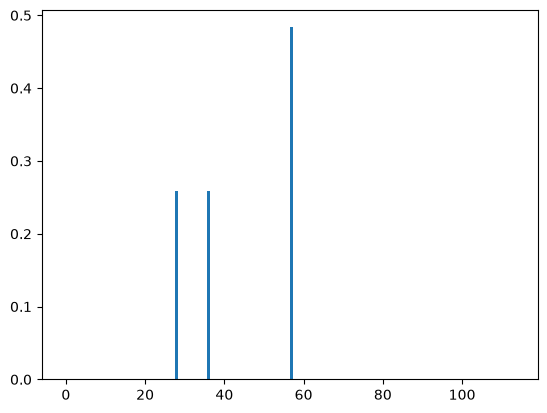

In [ ]:
plt.bar(np.arange(len(log_emit_vis[0])),np.exp(log_emit_vis[0]))